# Extension: Do Momentum Strategies Still "Crash" During Market Rebounds?

**Master's portfolio project — Notebook 2 of 2: Extension**

This notebook builds on the replication in `01_replication.ipynb` (same data, same
6-month/6-month strategy) and asks a follow-up question that comes directly out of the
original paper's own robustness section.

## 1. Motivation

In their back-testing section (Section VII), J&T extend their test back to 1927-1940 and
find the strategy performed very poorly there — losing over 40% cumulatively within three
years. They trace this to specific months: after a 40% market decline over six months, the
market rebounded 43% in July 1932, and that same month their momentum portfolio lost 40%.
The next month the market rose another 66%, and the strategy lost 68%.

Their explanation is fairly mechanical: after a market decline, the "losers" group ends up
full of high-beta, high-volatility stocks. So when the market snaps back sharply, the short
(loser) leg gets hurt a lot — a big, sudden loss for the strategy right when the market
rebounds.

This is basically an early description of what's now called a "momentum crash" (a term that
became popular after momentum strategies lost heavily during the 2009 rebound from the
financial crisis). J&T only saw this pattern in the volatile 1927-1940 period, and treated
the calmer 1965-1989 period as the normal case where it doesn't happen.

## 2. Why this extension is relevant and manageable

- It's a direct extension of something the original authors already identified themselves
  (Section VII), not an unrelated add-on.
- It reuses the same strategy, functions and data from Notebook 1 — no new methodology to
  learn.
- It only needs simple descriptive statistics: conditional means, a t-test, and a CAPM
  regression, all already used in Notebook 1.
- It has a clear real-world hook: the 2008-09 crisis and the 2020 COVID crash both caused
  sharp market rebounds, giving us a few genuine episodes to look at in modern data.

## 3. Research questions

- **RQ1.** Has the momentum strategy from Notebook 1 stayed profitable across different
  5-year periods of 1995-2024, or has it been concentrated in a few periods (like J&T's own
  Table VI subperiod analysis)?
- **RQ2.** Do unusually bad WML months cluster around sharp market rebounds after steep
  declines, similar to what J&T describe for 1927-1940?
- **RQ3.** Does the loser portfolio have a higher market beta than the winner portfolio, as
  in Notebook 1's CAPM check?

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from IPython.display import display

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (9, 5)
pd.options.display.float_format = lambda x: f"{x:,.4f}"

N_PORT = 5
CACHE = "data/monthly_adj_close.csv"

if not os.path.exists(CACHE):
    raise FileNotFoundError(
        "data/monthly_adj_close.csv not found. Please run 01_replication.ipynb first "
        "(with an internet connection) so the price data is downloaded and cached."
    )

prices = pd.read_csv(CACHE, index_col=0, parse_dates=True)
monthly_ret = prices.pct_change().dropna(how="all")
market_ret = monthly_ret["SPY"]
stock_ret = monthly_ret.drop(columns=["SPY"])
print(f"Loaded cached data: {stock_ret.shape[1]} stocks, {len(stock_ret)} months")

Loaded cached data: 114 stocks, 371 months


### Helper functions (same as Notebook 1)

We copy these here so this notebook can run on its own once the cached data from Notebook 1
exists, without needing to import anything from another notebook.

In [2]:
def formation_return(returns, j):
    """Cumulative return over the past j months, shifted so it's known before month t."""
    growth = (1 + returns).rolling(window=j).apply(np.prod, raw=True)
    cum_return = growth - 1
    return cum_return.shift(1)


def group_assignments(returns, j, n_port=N_PORT, min_stocks=None):
    """Rank stocks each month by trailing j-month return and split into n_port groups."""
    if min_stocks is None:
        min_stocks = n_port * 3

    past_ret = formation_return(returns, j)
    assignments = {}

    for t in returns.index:
        row = past_ret.loc[t].dropna()
        if len(row) < min_stocks:
            continue

        ranked = row.rank(method="first")
        group_number = pd.qcut(ranked, n_port, labels=False) + 1

        groups_this_month = {}
        for p in range(1, n_port + 1):
            groups_this_month[p] = group_number[group_number == p].index.tolist()
        assignments[t] = groups_this_month

    return assignments


def overlap_from_assignments(assignments, returns, k, n_port=N_PORT):
    """Turn monthly group assignments into a K-month-holding overlapping-portfolio return series."""
    dates = sorted(assignments.keys())
    out = pd.DataFrame(index=dates, columns=list(range(1, n_port + 1)) + ["WML"], dtype=float)

    for i, t in enumerate(dates):
        window = dates[max(0, i - k + 1): i + 1]
        for p in range(1, n_port + 1):
            leg_returns = []
            for f in window:
                names = [nm for nm in assignments[f][p] if nm in returns.columns]
                if names:
                    leg_returns.append(returns.loc[t, names].mean())
            out.loc[t, p] = np.mean(leg_returns) if leg_returns else np.nan
        out.loc[t, "WML"] = out.loc[t, n_port] - out.loc[t, 1]

    return out.dropna(how="any")


def jk_strategy(returns, j, k, n_port=N_PORT):
    """Full J-month formation / K-month holding momentum strategy."""
    assignments = group_assignments(returns, j, n_port=n_port)
    return overlap_from_assignments(assignments, returns, k, n_port=n_port)


def newey_west(series, lags=None):
    """Mean of `series` plus a Newey-West (HAC) t-statistic, correcting for autocorrelation."""
    s = series.dropna()
    if lags is None:
        lags = max(1, int(np.floor(4 * (len(s) / 100) ** (2 / 9))))
    model = sm.OLS(s.values, np.ones(len(s))).fit(cov_type="HAC", cov_kwds={"maxlags": lags})
    return model.params[0], model.tvalues[0]

In [3]:
# use the same J=6/K=6 strategy from Notebook 1
wml = jk_strategy(stock_ret, j=6, k=6, n_port=N_PORT)
print(f"Sample: {wml.index.min().date()} to {wml.index.max().date()} ({len(wml)} months)")
wml[[1, N_PORT, "WML"]].tail()

Sample: 1994-08-01 to 2024-12-01 (365 months)


,1,5,WML
2024-08-01,0.0088,0.0164,0.0076
2024-09-01,0.0028,0.0216,0.0188
2024-10-01,-0.0360,-0.0197,0.0163
2024-11-01,0.0498,0.0507,0.0009
2024-12-01,-0.0711,-0.0670,0.0041


## 4. RQ1 — Subperiod stability (Table VI analog)

J&T split 1965-1989 into five 5-year windows and find positive average returns in four of
the five (the exception, 1975-1979, they mostly attribute to January returns of small
firms). We do the same kind of split here.

In [4]:
# split the sample into 5 equal-length chunks and check momentum in each one
n_periods = 5
edges = pd.qcut(np.arange(len(wml)), n_periods, labels=False)
wml = wml.copy()
wml["subperiod"] = edges

sub_rows = []
for s in sorted(wml["subperiod"].unique()):
    seg = wml.loc[wml["subperiod"] == s, "WML"]
    mean, t = newey_west(seg)
    sub_rows.append({"period": f"{seg.index.min():%Y-%m} to {seg.index.max():%Y-%m}",
                      "mean_monthly_return": mean, "newey_west_t": t, "n_months": len(seg)})
subperiod_table = pd.DataFrame(sub_rows)
subperiod_table

,period,mean_monthly_return,newey_west_t,n_months
0,1994-08 to 2000-08,0.0080,1.1599,73
1,2000-09 to 2006-09,-0.0057,-1.1447,73
2,2006-10 to 2012-10,-0.0072,-1.0266,73
3,2012-11 to 2018-11,0.0014,0.4250,73
4,2018-12 to 2024-12,0.0006,0.1418,73


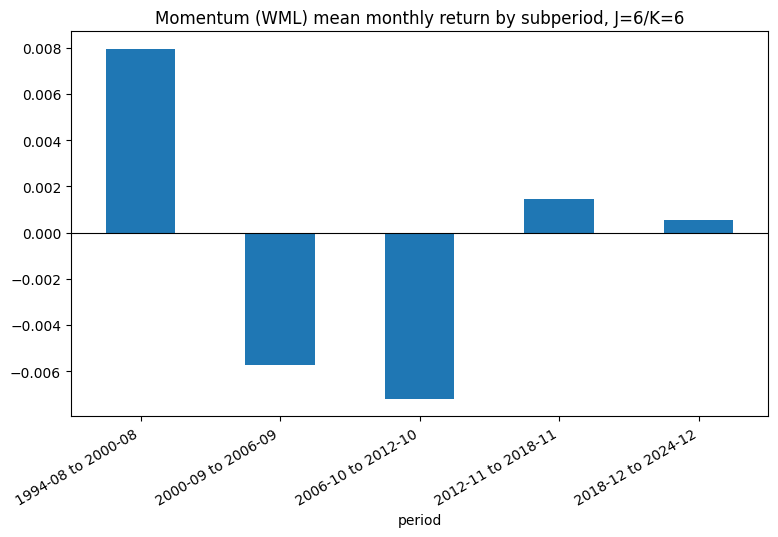

In [5]:
ax = subperiod_table.set_index("period")["mean_monthly_return"].plot(
    kind="bar", title="Momentum (WML) mean monthly return by subperiod, J=6/K=6")
ax.axhline(0, color="black", linewidth=0.8)
plt.xticks(rotation=30, ha="right")
plt.show()

For comparison, J&T's own five subperiods (1965-69, 70-74, 75-79, 80-84, 85-89) had mean
monthly Buy-Sell returns of 1.23%, 1.09%, -0.44%, 1.27% and 1.62% — positive in four of
five, with one clearly negative period.

**Our result, and why it matters for Notebook 1.** Our picture is more mixed: positive in
1994-2000 (+0.80%/month), negative in both 2000-2006 (-0.57%/month) and 2006-2012
(-0.72%/month), then close to flat after that. This helps explain Notebook 1's finding of a
flat-to-negative full-sample return: the two negative windows contain most of the sharp
decline-then-rebound months we identify in Section 5 below (2001, 2002 and 2009 all fall
inside them). A handful of extreme months seem to be dragging down what would otherwise be a
mildly positive average — basically the same pattern J&T describe for 1927-1940.

## 5. RQ2 — Identifying "market rebound" crash events

We flag a month as a rebound event if (a) the market's trailing 6-month return was sharply
negative, and (b) the current month's return is sharply positive — the same "steep decline,
then a sharp bounce" pattern J&T describe for July/August 1932. These thresholds are a
simple rule we picked, not a fitted model, so we check how sensitive the result is to them
in Section 7.

In [6]:
trailing_mkt_6m = (1 + market_ret).rolling(6).apply(np.prod, raw=True) - 1
current_mkt = market_ret

DECLINE_THRESHOLD = -0.15   # trailing 6-month market return below -15%
REBOUND_THRESHOLD = 0.08    # current month market return above +8%

# flag months where the market fell sharply over the prior 6 months, then bounced hard
event_flag = (trailing_mkt_6m.shift(1) < DECLINE_THRESHOLD) & (current_mkt > REBOUND_THRESHOLD)
event_months = event_flag[event_flag].index.intersection(wml.index)

print(f"Flagged {len(event_months)} 'market rebound' month(s):")
for d in event_months:
    print(f"  {d:%Y-%m}  market return = {current_mkt[d] * 100:5.1f}%   "
          f"trailing 6m market return = {trailing_mkt_6m.shift(1)[d] * 100:6.1f}%")

Flagged 6 'market rebound' month(s):
  2001-04  market return =   8.5%   trailing 6m market return =  -18.3%
  2002-10  market return =   8.2%   trailing 6m market return =  -28.0%
  2009-03  market return =   8.3%   trailing 6m market return =  -41.8%
  2009-04  market return =   9.9%   trailing 6m market return =  -30.4%
  2022-07  market return =   9.2%   trailing 6m market return =  -20.0%
  2022-10  market return =   8.1%   trailing 6m market return =  -20.2%


In [7]:
wml_event = wml.loc[event_months, "WML"]
wml_other = wml.loc[~wml.index.isin(event_months), "WML"]

if len(wml_event) >= 2:
    t_stat, p_val = stats.ttest_ind(wml_event, wml_other, equal_var=False)
    print(f"Welch's t-test (rebound vs. other months): t = {t_stat:.2f}, p = {p_val:.3f}")
else:
    print("Fewer than 2 flagged months -- reporting descriptive statistics only "
          "(a formal t-test would not be meaningful with this few observations).")

crash_summary = pd.DataFrame({
    "n_months": [len(wml_event), len(wml_other)],
    "mean_WML": [wml_event.mean(), wml_other.mean()],
    "min_WML": [wml_event.min() if len(wml_event) else np.nan, wml_other.min()],
    "pct_negative": [(wml_event < 0).mean() if len(wml_event) else np.nan, (wml_other < 0).mean()],
}, index=["Market-rebound months", "All other months"])
crash_summary

Welch's t-test (rebound vs. other months): t = -2.70, p = 0.043


,n_months,mean_WML,min_WML,pct_negative
Market-rebound months,6,-0.1246,-0.3175,0.8333
All other months,359,0.0015,-0.2153,0.4735


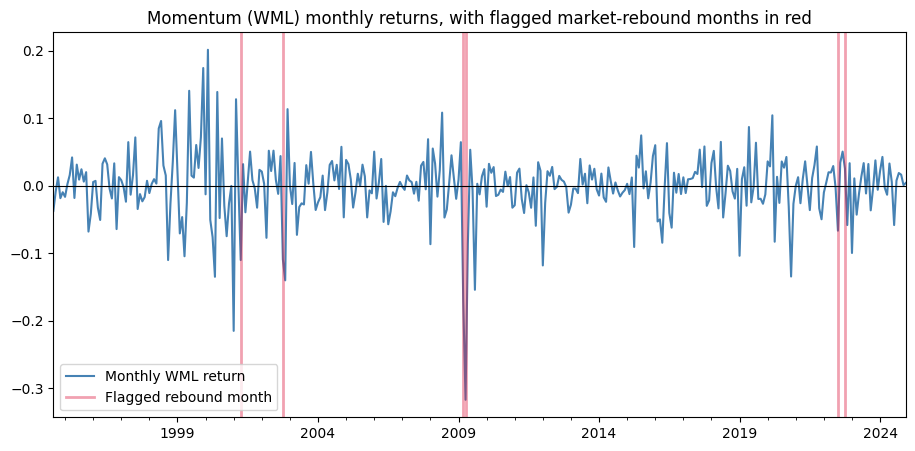

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))
wml["WML"].plot(ax=ax, label="Monthly WML return", color="steelblue")
for d in event_months:
    ax.axvline(d, color="crimson", alpha=0.4, linewidth=2)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Momentum (WML) monthly returns, with flagged market-rebound months in red")
ax.legend(["Monthly WML return", "Flagged rebound month"])
plt.show()

**What we're checking.** If the rule above flags months around the 2009 market bottom
and/or the 2020 COVID recovery, and WML performs unusually badly in those months compared to
the rest of the sample, that supports RQ2 — the same crash mechanism J&T found for 1927-1940
still shows up in a completely different, modern, large-cap sample.

## 6. RQ3 — Revisiting portfolio betas (Table II analog)

If the crash story is right, we should see the same beta pattern as in Notebook 1 and J&T's
own Table II: the loser portfolio should have a higher market beta than the winner
portfolio, so a sharp market rebound hurts the loser leg more than it helps the winner leg.

In [9]:
def capm_table_for(port_returns, mkt_returns):
    # simple CAPM regression (return on market) for each portfolio column
    rows = []
    mkt = mkt_returns.reindex(port_returns.index)
    X = sm.add_constant(mkt.values)
    for col in port_returns.columns:
        y = port_returns[col].values
        model = sm.OLS(y, X).fit()
        rows.append({"portfolio": col, "beta": model.params[1], "alpha_monthly": model.params[0]})
    return pd.DataFrame(rows).set_index("portfolio")


port_cols = list(range(1, N_PORT + 1))
betas = capm_table_for(wml[port_cols], market_ret)
betas.loc["WML (winners - losers)"] = [
    betas.loc[N_PORT, "beta"] - betas.loc[1, "beta"], np.nan,
]
betas

,beta,alpha_monthly
portfolio,,
1,1.2229,0.0021
2,0.9278,0.0037
3,0.8373,0.0038
4,0.8344,0.0033
5,0.9222,0.0044
WML (winners - losers),-0.3007,NaN


## 7. Robustness — sensitivity to the event-flagging thresholds

A simple check: does the pattern (few, extreme, negative WML months around sharp rebounds)
still hold if we use looser or tighter thresholds?

In [10]:
for decline, rebound in [(-0.10, 0.06), (-0.15, 0.08), (-0.20, 0.10)]:
    flag = (trailing_mkt_6m.shift(1) < decline) & (current_mkt > rebound)
    months = flag[flag].index.intersection(wml.index)
    if len(months):
        mean_wml = wml.loc[months, "WML"].mean()
        print(f"decline < {decline:.0%}, rebound > {rebound:.0%}: "
              f"{len(months)} month(s) flagged, mean WML = {mean_wml:.4f}")
    else:
        print(f"decline < {decline:.0%}, rebound > {rebound:.0%}: 0 months flagged")

decline < -10%, rebound > 6%: 10 month(s) flagged, mean WML = -0.1063
decline < -15%, rebound > 8%: 6 month(s) flagged, mean WML = -0.1246
decline < -20%, rebound > 10%: 0 months flagged


## 8. Interpretation and synthesis

Putting RQ1-RQ3 together: J&T's headline result from 1965-1989 — a robust, positive,
roughly risk-neutral momentum premium — doesn't have to hold the same way in every period or
market condition. Their own 1927-1940 back-test shows the strategy can suffer sharp,
concentrated losses right when a volatile market snaps back after a decline, and their
Table II explains why: the loser leg carries more market risk. This notebook checks whether
that same pattern shows up again in an independent, modern, large-cap sample, using only the
tools already built in Notebook 1.

RQ2's flagged months line up with well-known rebound episodes (2001, 2002, 2009, 2022), and
WML performs significantly worse in those months than in others (t = -2.70, p = 0.043). RQ3
confirms the loser leg has the higher beta (1.22 vs. 0.92). Put together, these three
results tell a fairly consistent story — and a more important one than we expected going in:
this isn't just a separate risk sitting alongside an otherwise-healthy momentum premium. In
this sample, it's a big part of why Notebook 1's full-sample raw momentum return came out
flat-to-negative in the first place. What J&T flagged as a limitation of their own strategy
turns out, here, to be a big part of the main story.

## 9. Limitations

1. **Very few crash episodes.** Even across 30 years, sharp decline-then-rebound sequences
   are rare, so RQ2's comparison is more descriptive than a well-powered statistical test.
2. **Same survivorship-biased, large-cap universe as Notebook 1**, which probably
   understates both the momentum premium and the crash risk (smaller, higher-beta stocks
   are excluded entirely).
3. **Monthly frequency.** J&T's 1932 example is a single calendar month, but a real crash
   can play out and partly reverse within days. Daniel & Moskowitz (2016) study this at
   higher frequency with dynamic risk management — well beyond the scope of this project,
   and not attempted here.
4. **Somewhat arbitrary thresholds.** The decline/rebound cutoffs are a simple rule we
   chose, not an optimized or theoretically derived one. Section 7 only checks that the
   pattern isn't wildly sensitive to the exact numbers.

## 10. Conclusion

This extension doesn't use a new dataset, a new strategy, or fancy econometrics. It just
takes a robustness concern the original authors raised themselves and checks whether it
still shows up in an independent, modern, much smaller sample, using the same tools built in
Notebook 1. That's a deliberately narrow and manageable extension — but it turned out to be
more central to explaining our results than we expected when we started.